## AISE4010- Assignment2 - Time Series Forecasting using CNN, RNN, LSTM and GRU

## Grade: 100 points

### Instructions

#### Follow These Steps before submitting your assignment 

1. Complete the notebook.

2. Make sure all plots have axis labels.

3. Once the notebook is complete, `Restart` your kernel by clicking 'Kernel' > 'Restart & Run All'.

4. Fix any errors until your notebook runs without any problems.

5. Submit one completed notebook for the group to OWL by the deadline.

6. Make sure to reference all external code and documentation used.

### ***lstm where is and output size question for assignment 2***

### ***check model architecture***
### ***none is technically 1***
### ***input/output: 128 input to 126 output because no padding, 9 to 64 because 9 features and 64 filters, 126 to 63 is because of max pooling***
### ***flatten = multiply last channels***
### ***lstm captures long term better but takes way longer***
### ***if differencing isnt enough = log transformation (from assignment 1)***
### ***difference between additive or multiplicative model: seasonal cycle magnitude doesnt change over time = use additive, seasonality goes up and down like an M = multiplicative model - default is additive***

### Dataset

The `StockData.csv` represents a time series dataset designed to simulate the behavior of stock prices over a period of 1000 days, starting from January 1, 2023. This dataset includes key features commonly found in stock market data, such as opening prices, closing prices, daily highs, daily lows, and trading volume. 

Features:
- Date: The timestamp representing the specific day for each record.
- Open: The stock's price at the start of the trading day. 
- High: The highest price of the stock during the trading day. It is generally higher than the opening price, reflecting intraday market movements.
- Low: The lowest price of the stock during the trading day. It is usually lower than the opening price, capturing downward movements in the market.
- Close: The stock’s price at the end of the trading day. This price reflects the market's closing valuation and fluctuates within a range close to the opening price.
- Volume: The number of shares traded during the day.

### Question 1 - Data Preprocessing (15%)
- Q1.1 Load the provided dataset and plot the `Closing prices` time series. (5%)
- Q1.2 (5%): 

  - a) Decompose the time series into its components and explain them.  
  - b) What do the trend and seasonality components tell you about the overall behavior of the time series? How does understanding     these components help in selecting a model for time series forecasting?
- Q1.3 Restructure the time series using a sliding window approach (with size 10) to prepare it for supervised learning. Split the `Closing prices` time series into 80% for training and 20% for testing. (5%)


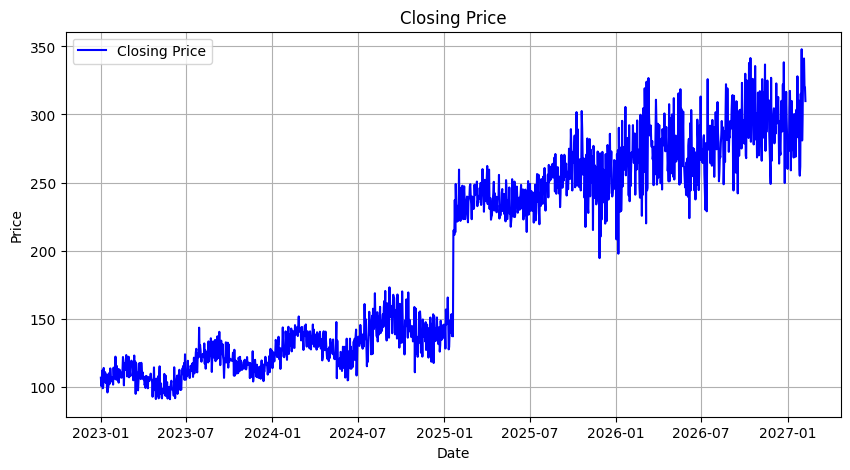

In [5]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/sixel/fourth_year/4410/assignments/2/StockData.csv", parse_dates=["Date"])

plt.figure(figsize=(10, 5))
plt.plot(df["Date"], df["Close"], label="Closing Price", color="blue")
plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

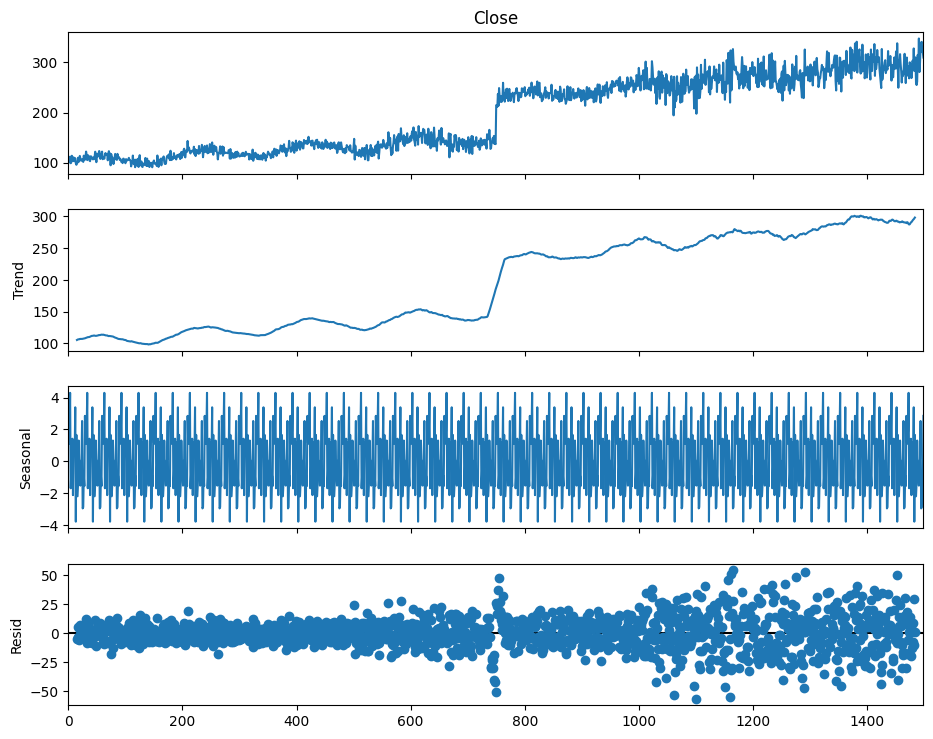

In [ ]:
#decompose to understand structure of time series
from statsmodels.tsa.seasonal import seasonal_decompose

#assume monthly seasonality first since unsure of trend
decomposition = seasonal_decompose(df["Close"], model='additive', period=30) #30 for monthly
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()

**What do the trend and seasonality components tell you about the overall behavior of the time series? How does understanding these components help in selecting a model for time series forecasting?**

The trend demonstrates that the data increases gradually with noticeable jumps, showing upward movement in price. The seasonal component shows regular oscillations repeating monthly (which shows our monthly seasonality estimate was true). Lastly, there is no major error/noise since residuals scatter randomly around zero. 


These can help model selection since strong trends can indicate that ideal models could include ARIMA/SARIMA or LSTM, and seasonality can indicate that CNN or LSTM could be a good selection. 

In [ ]:
import numpy as np

#extract closing price column into array
closing_prices = df["Close"].values

#create sliding windows to make input/output pairs
window_size = 10
x,y = [],[]

for i in range (len(closing_prices) - window_size): #create input/output pairs
    x.append(closing_prices[i:i+window_size])
    y.append(closing_prices[i+window_size])

x=np.array(x)
y=np.array(y)

#split into train test
split_index = int(.8*len(x))
x_train, x_test = x[:split_index], x[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Testing shape:", y_test.shape)

Training samples: 1192
Testing samples: 298
Testing shape: (298,)


### Question2 - 1D Convolutional Neural Network (CNN) (20%)
- Q2.1 Create a 1D CNN model for time series forecasting. The model should have two convolutional layers of size 64 and 32 and kernel size of 3, fully connected layer of size 50, droup out of 0.3, and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 32, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q2.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q2.3 How does the 1D-CNN perform in terms of capturing short-term dependencies? Based on the RMSE and MAE values, do you think this model can effectively capture long-term trends? Why or why not? (2%)


Training shape: (1192, 10, 1)
Testing shape: (298, 10, 1)


c:\Users\sixel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_10 (Conv1D)              │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 6, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50)             │         9,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,133 (63.02 KB)

 Trainable params: 16,133 (63.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6170.1270 - mae: 59.5146 - val_loss: 554.2787 - val_mae: 19.3863
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 663.3253 - mae: 19.1943 - val_loss: 604.5308 - val_mae: 19.6826
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 528.0931 - mae: 17.2837 - val_loss: 528.9089 - val_mae: 18.5303
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 458.5044 - mae: 15.8024 - val_loss: 822.0730 - val_mae: 23.0421
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 395.9825 - mae: 14.7109 - val_loss: 937.5422 - val_mae: 24.8791
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 448.2184 - mae: 15.5660 - val_loss: 475.6285 - val_mae: 17.5885
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 390.8536 - mae: 14.9968 - val_loss: 895.4588 - val_mae: 24.1872
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 407.3491 - mae: 15.0318 - val_loss: 878.8290 - val_mae: 23.9144
Epoch 9/50
38/38 ━━━━━

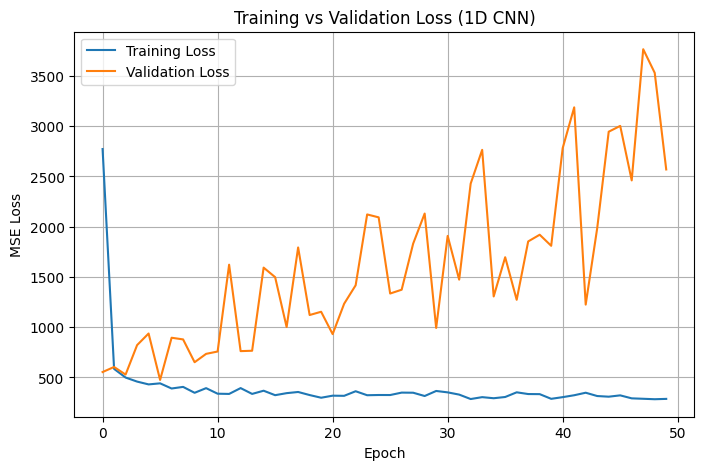

In [ ]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

#reshape data for CNN = batch, steps, channels (channel =1)
x_train_cnn = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_cnn = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
print("Training shape:", x_train_cnn.shape)
print("Testing shape:", x_test_cnn.shape)

#build model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(10,1)), #output is batch,8,64
    Conv1D(filters=32, kernel_size=3, activation='relu'), #output is batch, 6, 32
    Dropout(0.3), #regularization
    Flatten(), #6*32 = 192
    Dense(50,activation = 'relu'), #50 neurons
    Dense(1)
])
model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])
model.summary()

#train
start_train=time.time()
history = model.fit(
    x_train_cnn,y_train, epochs=50, batch_size=32, 
    validation_data=(x_test_cnn, y_test), verbose=1
)
end_train=time.time()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (1D CNN)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
RMSE: 50.6941
MAE: 6.7858


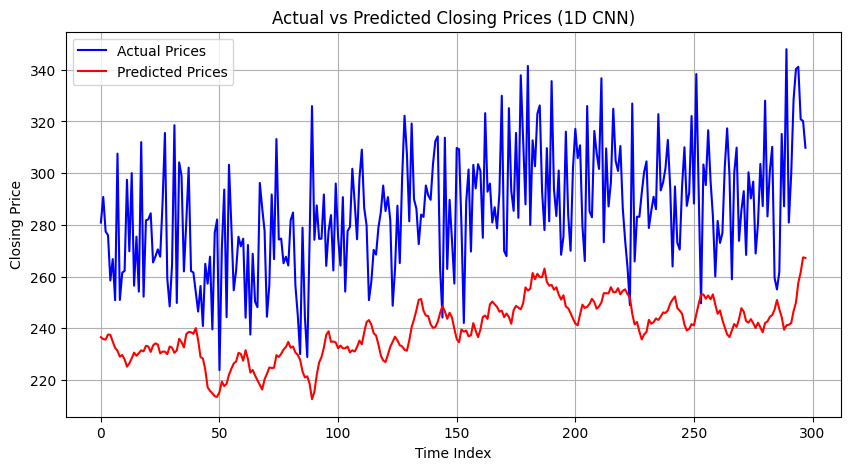


Testing Time: 0.09 seconds

Training Time: 9.25 seconds


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

#predict values
start_test = time.time()
y_pred = model.predict(x_test_cnn)
end_test = time.time()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.sqrt(mean_absolute_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(y_pred, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Closing Prices (1D CNN)')
plt.xlabel('Time Index')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

testing_time = end_test - start_test
print(f"\nTesting Time: {testing_time:.2f} seconds")
training_time = end_train - start_train
print(f"\nTraining Time: {training_time:.2f} seconds")

**How does the 1D-CNN perform in terms of capturing short-term dependencies? Based on the RMSE and MAE values, do you think this model can effectively capture long-term trends? Why or why not? (2%)** 

The 1D CNN performs well in capturing long term dependencies since convolutional filters are effective at detecting local patterns/short-term fluctuations - this can be validating since the MAE is relatively low. However, the RMSE is pretty high, suggesting that the model struggles with long term trends. This is because CNN have a limitied receptive field (they concentrate on trends within sliding window).

### Question 3 - Recurrent Neural Networks (RNN) (20%)
- Q3.1 Create an RNN model for time series forecasting. The model should include a SimpleRNN layer of size 40 and ReLU activation. Train the model using the provided dataset for 50 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q3.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q3.3 Why did we use a smaller batch size compared to CNN model. Why might RNN struggle with long-term dependencies, and how is this reflected in the evaluation metrics? (2%)


Training shape: (1192, 10, 1)
Testing shape: (298, 10, 1)


c:\Users\sixel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 40)             │         1,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,721 (6.72 KB)

 Trainable params: 1,721 (6.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 24030.9648 - mae: 130.3781 - val_loss: 653.2000 - val_mae: 21.3450
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 173.3863 - mae: 9.3663 - val_loss: 503.9134 - val_mae: 18.4376
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 167.3700 - mae: 9.0571 - val_loss: 474.8470 - val_mae: 17.5101
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 187.7599 - mae: 9.3035 - val_loss: 569.1490 - val_mae: 18.8994
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 182.7910 - mae: 9.5666 - val_loss: 470.4849 - val_mae: 17.4466
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 164.4065 - mae: 8.7962 - val_loss: 518.8908 - val_mae: 18.0710
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 159.5241 - mae: 8.9332 - val_loss: 468.9923 - val_mae: 17.4921
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 160.6835 - mae: 9.2122 - val_loss: 492.3474 - val_mae: 17.6309
Epoch 9/50
75/75 ━━━━━━━━━━━

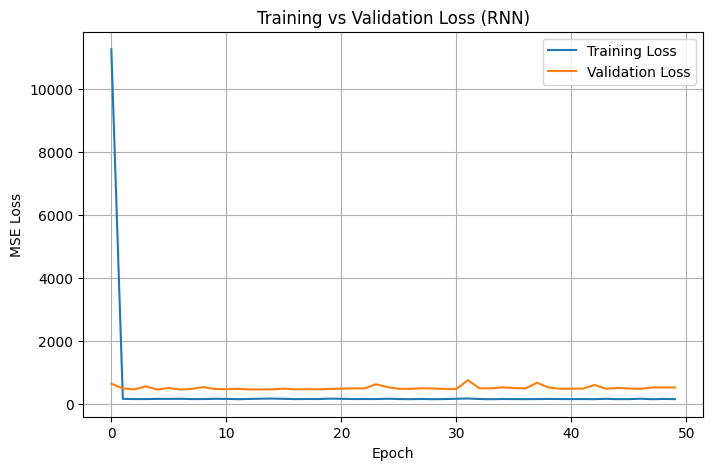

In [ ]:
from tensorflow.keras.layers import SimpleRNN

#reshape data into samples, timesteps, features, feature =1
x_train_rnn = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_rnn = x_test.reshape((x_test.shape[0], x_train.shape[1], 1))
print("Training shape:", x_train_rnn.shape)
print("Testing shape:", x_test_rnn.shape)

#build model
model_rnn = Sequential([
    SimpleRNN(40, activation='relu', input_shape=(10, 1)), #40 neurons
    Dense(1)
])
model_rnn.compile(optimizer=Adam(), loss='mse', metrics=['mae'])
model_rnn.summary()

#train
start_train = time.time()
history_rnn = model_rnn.fit(
    x_train_rnn, y_train, epochs = 50, batch_size = 16, 
    validation_data=(x_test_rnn, y_test), verbose =1
)
end_train = time.time()

plt.figure(figsize=(8,5))
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (RNN)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RNN RMSE: 23.1639
RNN MAE: 18.4549


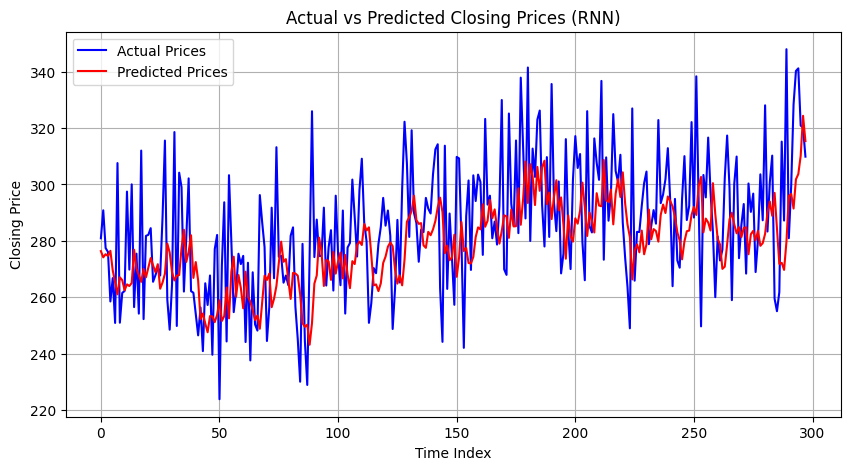


Testing Time: 0.35 seconds

Training Time: 11.41 seconds


In [37]:
#predict y
start_test = time.time()
y_pred_rnn = model_rnn.predict(x_test_rnn)
end_test = time.time()

rmse_rnn=np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
print(f"RNN RMSE: {rmse_rnn:.4f}")
print(f"RNN MAE: {mae_rnn:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(y_pred_rnn, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Closing Prices (RNN)')
plt.xlabel('Time Index')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

testing_time = end_test - start_test
print(f"\nTesting Time: {testing_time:.2f} seconds")
training_time = end_train - start_train
print(f"\nTraining Time: {training_time:.2f} seconds")

**Why did we use a smaller batch size compared to CNN model. Why might RNN struggle with long-term dependencies, and how is this reflected in the evaluation metrics? (2%)** 

A smaller batch size was used since they process data sequentially, maintaining dependencies between time steps. Smaller batch sizes help preserve order and continuity of time series, allowing the RNN to better capture temporal relationships during training. RNN Struggle with long term dependencies (due to gradient vanishing/exploding), which is reflected in the higher MAE compared to the CNN.

### Question 4 - Long Short-Term Memory (LSTM) (20%)
- Q4.1 Create an LSTM model for time series forecasting.The model should include two LSTM layers of size 100 and 50, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q4.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series. (6%)
- Q4.3 Why do we use a larger epoch compared to RNN? (2%)

Training shape: (1192, 10, 1)
Testing shape: (298, 10, 1)


c:\Users\sixel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,051 (277.54 KB)

 Trainable params: 71,051 (277.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2288.7983 - mae: 29.0440 - val_loss: 473.0180 - val_mae: 17.6756
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 236.6345 - mae: 10.1544 - val_loss: 467.3809 - val_mae: 17.5117
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 198.9037 - mae: 9.8115 - val_loss: 492.2921 - val_mae: 18.0201
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 197.8462 - mae: 9.9203 - val_loss: 464.4045 - val_mae: 17.4859
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 190.4241 - mae: 9.6012 - val_loss: 474.3164 - val_mae: 17.6248
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 166.0282 - mae: 9.0828 - val_loss: 469.1686 - val_mae: 17.5484
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 197.5830 - mae: 9.8830 - val_loss: 478.1077 - val_mae: 17.5150
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 181.8846 - mae: 8.9728 - val_loss: 484.9651 - val_mae: 17.6368
Epoch 9/100
75/75 ━━

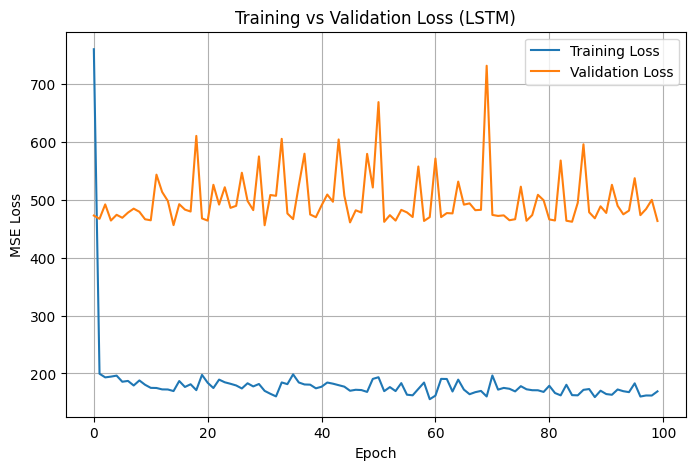

In [ ]:
from tensorflow.keras.layers import LSTM

#reshape data into samples, timesteps, features, feature=1
x_train_lstm = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_lstm = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
print("Training shape:", x_train_lstm.shape)
print("Testing shape:", x_test_lstm.shape)

#build model
model_lstm = Sequential([
    LSTM(100, activation = 'relu', return_sequences =True, input_shape=(10, 1)), #100 nerons
    LSTM(50, activation = 'relu'), #50 neurons
    Dense(1)
])

model_lstm.compile(optimizer=Adam(), loss='mse', metrics=['mae'])
model_lstm.summary()

#train
start_train = time.time()
history_lstm = model_lstm.fit (
    x_train_lstm, y_train, epochs = 100, batch_size =16, 
    validation_data=(x_test_lstm, y_test), verbose=1
)
end_train = time.time()

plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
LSTM RMSE: 21.5321
LSTM MAE: 17.2429


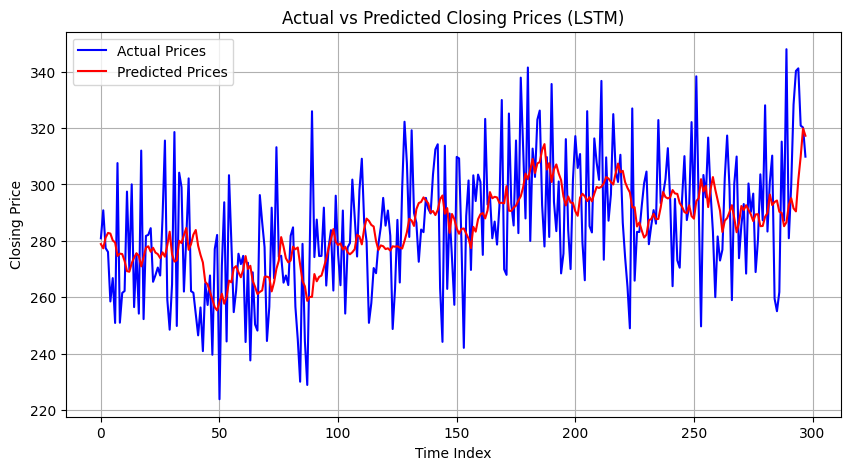


Testing Time: 0.68 seconds

Training Time: 50.87 seconds


In [39]:
#predict
start_test = time.time()
y_pred_lstm=model_lstm.predict(x_test_lstm)
end_test = time.time()

rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
print(f"LSTM RMSE: {rmse_lstm:.4f}")
print(f"LSTM MAE: {mae_lstm:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(y_pred_lstm, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Closing Prices (LSTM)')
plt.xlabel('Time Index')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

testing_time = end_test - start_test
print(f"\nTesting Time: {testing_time:.2f} seconds")
training_time = end_train - start_train
print(f"\nTraining Time: {training_time:.2f} seconds")

**Why do we use a larger epoch compared to RNN? (2%)** 

LSTM are better at capturing long term dependencies more effectively due to their memory and gating mechanisms. However, this added complexity means they require more epochs to fully learn relationships. Their slightly higher RMSE compared to the RNN (which has less epochs) suggests that it needs longer training to acheive similar results. 

### Question 5 - Gated Recurrent Unit (GRU) (20%)
- Q5.1 Create a GRU model for time series forecasting.The model should include two GRU layers of size 80 and 40, and ReLU activation. Train the model using the provided dataset for 100 epochs. Use the batch_size of 16, and ADAM optimizer. Plot the training loss and validation loss. (12%)
- Q5.2 Evaluate the model's performance using RMSE and MAE on the test set. Plot the predicted values alongside the actual values to visualize how well the model is forecasting the time series.(6%)
- Q5.3 How does the GRU compare to LSTM in terms of computational efficiency and forecasting performance? (2%)

Training shape: (1192, 10, 1)
Testing shape: (298, 10, 1)


c:\Users\sixel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 10, 80)         │        19,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 40)             │        14,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,601 (135.16 KB)

 Trainable params: 34,601 (135.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 11416.7061 - mae: 79.7576 - val_loss: 480.3738 - val_mae: 17.6716
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 183.0501 - mae: 9.4941 - val_loss: 504.2285 - val_mae: 17.6735
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 156.0650 - mae: 9.0136 - val_loss: 495.5784 - val_mae: 17.5318
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 163.3680 - mae: 9.2885 - val_loss: 477.8198 - val_mae: 17.3635
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 169.4285 - mae: 9.0967 - val_loss: 501.0505 - val_mae: 17.6954
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 182.8472 - mae: 9.5089 - val_loss: 461.8784 - val_mae: 17.2408
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 173.0766 - mae: 9.0280 - val_loss: 466.9812 - val_mae: 17.3379
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 177.9890 - mae: 9.4161 - val_loss: 474.2579 - val_mae: 17.2749
Epoch 9/100
75/75 ━━

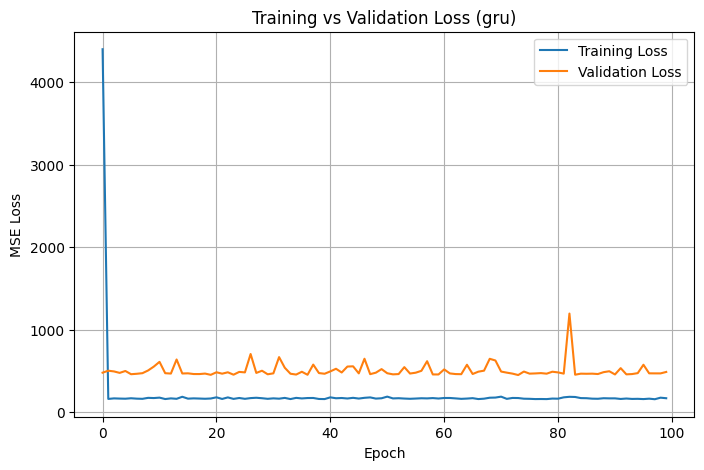

In [ ]:
from tensorflow.keras.layers import GRU

#reshape data to be samples, timesteps, features, feature=1
x_train_gru = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test_gru = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))
print("Training shape:", x_train_gru.shape)
print("Testing shape:", x_test_gru.shape)

#build model
model_gru = Sequential([
    GRU(80, activation = 'relu', return_sequences =True, input_shape=(10, 1)), #80 neurons
    GRU(40, activation = 'relu'), #40 neurons
    Dense(1)
])

model_gru.compile(optimizer=Adam(), loss='mse', metrics=['mae'])
model_gru.summary()

#train
start_train = time.time()
history_gru = model_gru.fit (
    x_train_gru, y_train, epochs = 100, batch_size =16, 
    validation_data=(x_test_gru, y_test), verbose=1
)
end_train = time.time()

plt.figure(figsize=(8,5))
plt.plot(history_gru.history['loss'], label='Training Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (gru)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
LSTM RMSE: 22.1197
LSTM MAE: 17.4700


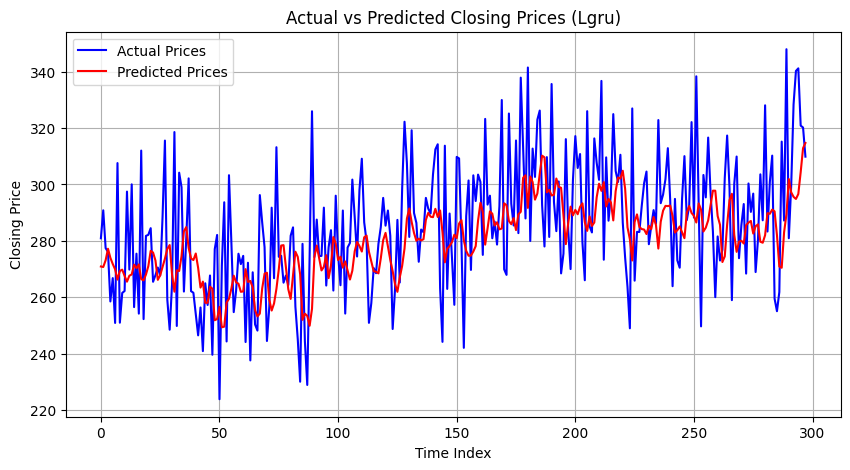


Testing Time: 0.78 seconds

Training Time: 55.13 seconds


In [41]:
#predict
start_test = time.time()
y_pred_gru=model_gru.predict(x_test_gru)
end_test = time.time()

rmse_gru = np.sqrt(mean_squared_error(y_test, y_pred_gru))
mae_gru = mean_absolute_error(y_test, y_pred_gru)
print(f"LSTM RMSE: {rmse_gru:.4f}")
print(f"LSTM MAE: {mae_gru:.4f}")

plt.figure(figsize=(10,5))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(y_pred_gru, label='Predicted Prices', color='red')
plt.title('Actual vs Predicted Closing Prices (Lgru)')
plt.xlabel('Time Index')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.show()

testing_time = end_test - start_test
print(f"\nTesting Time: {testing_time:.2f} seconds")
training_time = end_train - start_train
print(f"\nTraining Time: {training_time:.2f} seconds")

**How does the GRU compare to LSTM in terms of computational efficiency and forecasting performance? (2%)** 

GRUs are more computationally efficient than LSTMs because they use fewer gates and have simple architecture, reducing training time and memory usage. Despite this, GRUs acheive comparable forecasting performance. In this case, GRU acheived a lower RMSE and MAE than the lSTM, indicating slightly better accuracy. 

### Question 6 - Discussion (5%)
- Q6.1 Compare the performance of 1D-CNN, RNN, LSTM, and GRU models based on training and test execution time, performance (RMSE and MAE), and potential overfitting/underfitting. (3%)
- Q6.2 Discuss in which cases you would prefer using 1D-CNN vs LSTM or GRU for time series data. (2%)


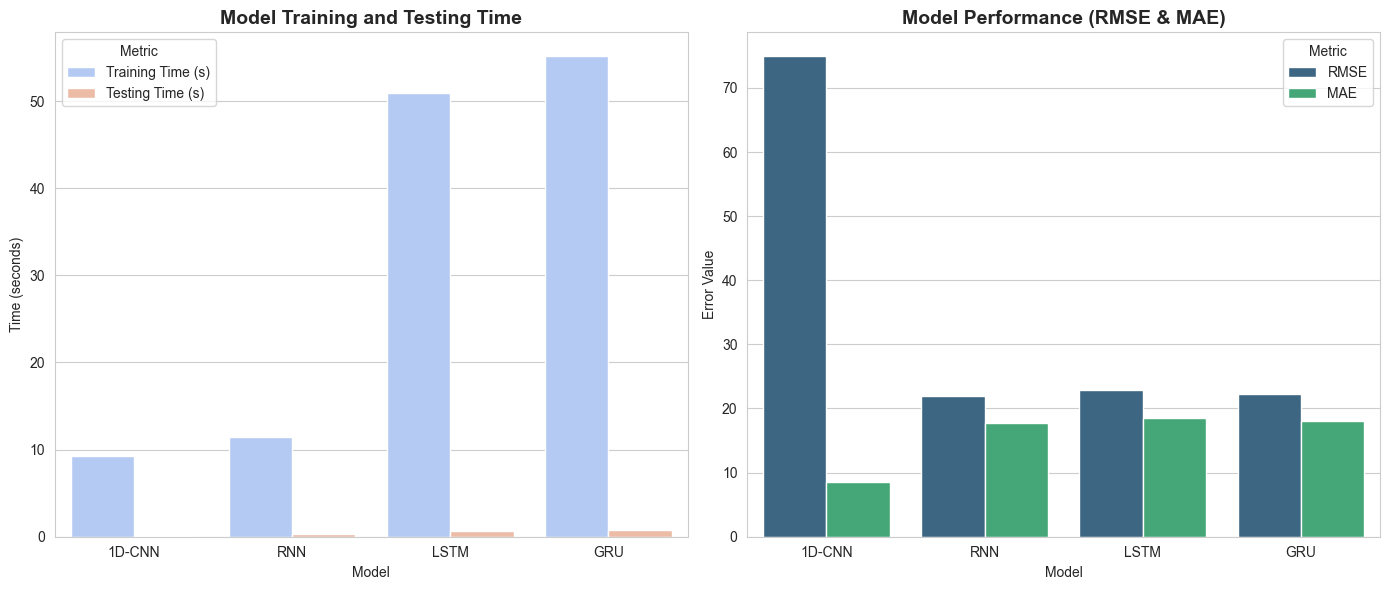

In [42]:
import seaborn as sns

data = {
    "Model": ["1D-CNN", "RNN", "LSTM", "GRU"],
    "Training Time (s)": [9.25, 11.41, 50.87, 55.13],
    "Testing Time (s)": [0.09, 0.35, 0.68, 0.78],
    "RMSE": [74.92, 22.02, 22.84, 22.20],
    "MAE": [8.48, 17.76, 18.57, 18.00]
}
df = pd.DataFrame(data) 

sns.set_style("whitegrid")
plt.figure(figsize=(14, 6))

#training and testing time
plt.subplot(1, 2, 1)
sns.barplot(data=df.melt(id_vars="Model", value_vars=["Training Time (s)", "Testing Time (s)"]),
            x="Model", y="value", hue="variable", palette="coolwarm")
plt.title("Model Training and Testing Time", fontsize=14, weight='bold')
plt.ylabel("Time (seconds)")
plt.xlabel("Model")
plt.legend(title="Metric")

#rmse and mae
plt.subplot(1, 2, 2)
sns.barplot(data=df.melt(id_vars="Model", value_vars=["RMSE", "MAE"]),
            x="Model", y="value", hue="variable", palette="viridis")
plt.title("Model Performance (RMSE & MAE)", fontsize=14, weight='bold')
plt.ylabel("Error Value")
plt.xlabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

**Compare the performance of 1D-CNN, RNN, LSTM, and GRU models based on training and test execution time, performance (RMSE and MAE), and potential overfitting/underfitting. (3%)** The 1D CNN is the fastest model, but performs the worst for long term forecasting. RNN improves slightly but remains limited by gradient issues. LSTM and GRU acheive lower errors but require significantly more training time, showing a trade-off between accuracy and computational cost. LSTM and GRU also show mild overfitting as their validation losses plateau slower than training losses. 

**Discuss in which cases you would prefer using 1D-CNN vs LSTM or GRU for time series data. (2%)** When the dataset is large, noise tolerant and the goal is to capture short term patterns quickly, use 1D CNN. When long term dependencies are the most important or the dataset has complex temporal structures usr LSTM or GRU (GRU has fewer parameters and trains faster). 